<center><font size=5><b>Extracting harmonics of $\phi$-dependent data in Gepard - The case of CLAS 2022 A_LU</b></font></center>

# Intro

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [5]:
from scipy.optimize import curve_fit

In [2]:
import gepard as g
print(g.__version__)

0.9.11b0


In [6]:
# This just gets my current git revision hash, in case version number above is not reliable.
# You should comment this cell out if your Gepard installation is not git cloned from github repository.
import os
import subprocess
branch = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                  'branch', '--show-current']).decode('ascii').strip()
revhash = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                   'rev-parse', 'HEAD']).decode('ascii').strip()
print('Current git branch is "{}" and revision hash is {}'.format(branch, revhash))

Current git branch is "dev_Mel" and revision hash is dd5e2aceae4d24c8f1365249b8d77a273a66969e


In [7]:
def plotpts(bin1, bin2=None, replica=None):
    """Plot points in bin with errorbars."""
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    if isinstance(bin2, pd.DataFrame):
        ax.errorbar(bin2.phi.values, bin2.val.values, bin2.err.values, color='red', linestyle='None',
                   capsize=2)
    if isinstance(replica, np.ndarray):
        ax.plot(bin1.phi.values, replica, marker='o', color='red', linestyle='None')
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [8]:
def plotFT(dfs, cosmax, sinmax):
    """Plot harmonics with with errorbars."""
    CM = cosmax
    SM = sinmax
    fig, ax = plt.subplots(1,1, figsize=[6,6])
    shift = 0
    for df in dfs:
        c = df.val.values[:CM+1]
        delc = df.err.values[:CM+1]
        s = df.val.values[CM+1:CM+SM+1]
        dels = df.err.values[CM+1:CM+SM+1]
        ax.errorbar(np.arange(CM+1)+shift, c, delc, linestyle='None', capsize=3,color='blue')
        ax.errorbar(np.arange(-1,-SM-1,-1)+shift, s, dels, linestyle='None', capsize=3, color='red')
        shift += 0.05
    ax.axhline(linestyle='-.', color='green', linewidth=0.5)
    ax.axvline(linestyle='-.', color='green', linewidth=0.5)
    #ax.legend(loc=4, fontsize=14).draw_frame(1)
    fig.savefig('fig')

In [9]:
def csmax(N):
    """Returns largest cos and sin indices for N points in a bin."""
    cosmax = int((N-1)/2.)
    sinmax = cosmax + ((N-1) % 2)
    assert cosmax + sinmax == N - 1
    return (cosmax, sinmax)

In [10]:
# For check, we compare FT results to simple CLAS-like curve fit
def clasfit(df):
    """Fits A*sin(phi)/(1+B*cos(phi)) to a single xB-Q2-t bin in Pandas dataframe df."""
    # Define your model function
    def model_func(phi, A, B):
        return A * np.sin(phi) / (1 + B * np.cos(phi))
    
    # Assume your DataFrame is named df and has columns: 'phi', 'val', 'err'
    # Example: df = pd.DataFrame({'phi': ..., 'val': ..., 'err': ...})
    
    # Extract numpy arrays from DataFrame
    phi = df['phi'].values
    val = df['val'].values
    err = df['err'].values
    
    # Perform the fit using weights = 1/err^2
    popt, pcov = curve_fit(
        model_func,
        phi,
        val,
        sigma=err,
        absolute_sigma=True,  # use sigma to scale the covariance matrix
        p0=(1.0, 0.0)         # initial guesses for A and B
    )
    
    # Extract fit parameters and uncertainties
    A_fit, B_fit = popt
    A_err, B_err = np.sqrt(np.diag(pcov))
    
    # Print results
    # print(f"A = {A_fit:.6f} ± {A_err:.6f}")
    # print(f"B = {B_fit:.6f} ± {B_err:.6f}")
    return float(A_fit), float(A_err)

In [11]:
def gridplot(k):
    phis = np.linspace(-np.pi, np.pi, 80)  # used for sine curve
    
    fig, axes = plt.subplots(3, 3, figsize=[12, 12])
    axes = axes.flatten()
    
    for i in range(9):
        ki = k + i
        df = binALU[ki]
        ax = axes[i]
        
        ax.errorbar(df.phi.values, df.val.values, df.err.values, color='blue',
                    linestyle='None', capsize=3)
        
        amp = df.iloc[0].FTval
        ax.plot(phis, amp * np.sin(phis), color='red', linestyle='solid', lw=2)
        
        ax.set_ylim(-0.5, 0.5)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_title(f'binALU[{ki}]')
    
    plt.tight_layout()
    fig.savefig('fig_grid')

# Basic extraction of harmonics

In [11]:
ID = 149   # Gepard ID of a dataset

In [12]:
g.describe_data(g.dset[ID])

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
1535 x ALU     CLAS    N/A    149 arXiv:2211.11274
----------------------------------------------
TOTAL = 1535


We transform Gepard dataset into Pandas dataframe and take just some relevant columns.

In [13]:
dfALU = g.dset[ID].df()[['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'err', 'errstat', 'errsyst']]

Gepard's FT routines below work with `err` as uncertainty to be FT-transformed. This
should be only statistical uncertainty, while systematic uncertainty should be added
in quadrature after FT (if you don't decide to do some even more sophisticated approach).
Thus, if data has separate `errstat` column we should rename it into `err`:

In [14]:
if 'err' in dfALU.columns:
    dfALU.rename(columns={'err': 'errtot'}, inplace=True)   # cannot have two err columns
dfALU.rename(columns={'errstat': 'err'}, inplace=True)

Now we detect bins, assuming that dataset rows are ordered on (Q2, xB, tm) whatever order but phi last, and then
relying on wraparound behaviour of phi values at the end of the bin.

In [15]:
# Detect bin breaks based on increasing phi jumps
phi_diff = dfALU['phi'].diff().fillna(0)
bin_starts = [0] + list(phi_diff[phi_diff > 2.5].index) + [len(dfALU)]

# Initialize bin dictionary and list for bin centers
binALU = {}
bin_centers = []

# Loop over bins
for k in range(len(bin_starts) - 1):
    start = bin_starts[k]
    end = bin_starts[k + 1]
    df_bin = dfALU.iloc[start:end].copy().reset_index(drop=True)
    
    # Compute central values
    Q2_mean = df_bin['Q2'].mean()
    xB_mean = df_bin['xB'].mean()
    tm_mean = df_bin['tm'].mean()
    
    # Add central values to each row of the bin
    df_bin['Q2_center'] = Q2_mean
    df_bin['xB_center'] = xB_mean
    df_bin['tm_center'] = tm_mean
    
    # Save
    binALU[k] = df_bin
    bin_centers.append({'Q2': Q2_mean, 'xB': xB_mean, 'tm': tm_mean})

# Create bins dataframe from collected central values
bins = pd.DataFrame(bin_centers)
print('Number of all bins = {}'.format(len(bins)))

Number of all bins = 102


There is a Gepard function `FTFMC` that will, for given bin, by default extract all harmonics using discrete Fourier transform and Monte Carlo uncertainty propagation.

Sometimes (first observed for 2022 CLAS A_LU) for observables
such as X_LU or A_LU which are known to vanish at phi = 0 degrees, one needs to enforce this by removing cos(phi)
harmonics from the analysis (especially troublesome is cos(0*phi)). This is done by specifying cosmax=-1 to FTFMC. In
this case, one can also limit the number of sine harmonics by sinmax.

In [16]:
cm = -1; sm = +2

In [17]:
dfphi = binALU[0]  # Some example bin

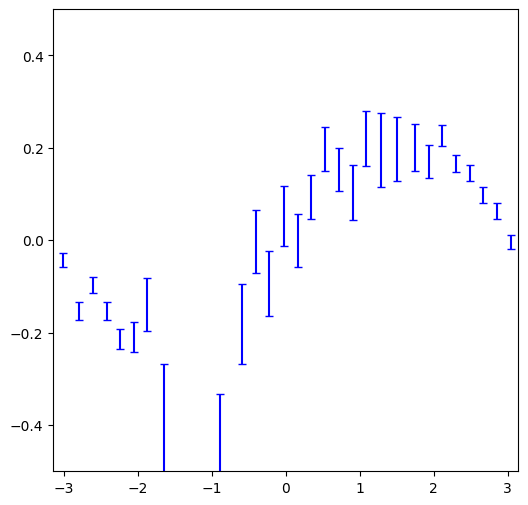

In [18]:
plotpts(dfphi)

In [19]:
dfFT = g.data.FTFMC(dfphi, cosmax=cm, sinmax=sm)

Be careful. Dataframe that is returned still has `phi` values but they don't make sense here (they are just kept for later cross-check). First (N-1/2) values are cosine harmonics, and rest are sine:

In [20]:
dfFT.head(5)

,phi,val,err
0,3.045959,0.251189,0.017939
1,2.856589,0.018747,0.014088
2,2.671345,0.000000,0.000000
3,2.483866,0.000000,0.000000
4,2.294601,0.000000,0.000000


In [21]:
# First sine harmonic should be roughly consistent with a simple CLAS-like fit:
clasfit(dfphi)

(0.23589426818747142, 0.014581174064878032)

`FTFMC(df, inverse=True)` will do the inverse FT so you can check the whole procedure for consistency:

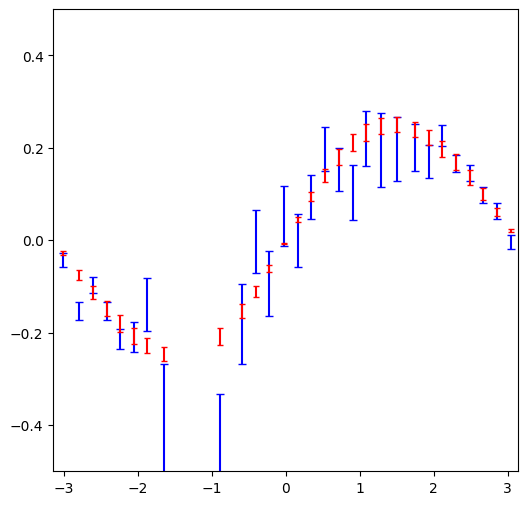

In [22]:
plotpts(dfphi, g.data.FTFMC(g.data.FTFMC(dfphi, cosmax=cm, sinmax=sm), inverse=True, cosmax=cm, sinmax=sm))

Above, double-FT red data should be statistically the same as the original blue data, at least regarding the sine harmonics.

There is also a somewhat experimental function `FTanalyse` that can take a set of bins and determine by cross-validation procedure how many harmonics are "visible" in this data:

In [23]:
cosmax, sinmax = g.data.FTanalyse(binALU)

Highest extractable cos harmonic = 0.529 +- 0.696
Highest extractable sin harmonic = 1.196 +- 0.642



For final harmonic analysis we increase the number of Monte Carlo samples and store the results in two new dataframe columns:

In [24]:
for k in range(len(bins)):
    dfFT = g.data.FTFMC(binALU[k], cosmax=cm, sinmax=sm, nsamples = 3000)
    binALU[k]['FTval'] = pd.Series(dfFT['val'].values, index=binALU[k].index)
    binALU[k]['FTerr'] = pd.Series(dfFT['err'].values, index=binALU[k].index)

In [25]:
binALU[4].columns

Index(['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'errtot', 'err', 'errsyst',
       'Q2_center', 'xB_center', 'tm_center', 'FTval', 'FTerr'],
      dtype='object')

In [26]:
def s1(bin):
    """Take just first sine harmonic of bin with error."""
    s1ind = cm + 1 # index of first sine harmonic
    return bin[['Q2_center', 'xB_center', 'tm_center', 'in1energy', 'FTval', 'FTerr']].iloc[s1ind]

We unite all bins, taking value and uncertainty of just calculated first sine harmonic (FTval and FTerr), and
we also calculate average and maximal systematic error for given bin. One can than choose which of the two
to take as the proper systematic error of the harmonic (more sophisticated treatment could be implemented here by the person who understands systematics better).


In [27]:
FTs1 = pd.DataFrame([pd.concat([s1(binALU[k]),
                                pd.Series([binALU[k]['errsyst'].mean(),
                                                     binALU[k]['errsyst'].max()], index=['avgsyst', 'maxsyst'])])
                     for k in bins.index]).reset_index(drop=True)

This (after maybe some reduction of significant digits) can now be saved into the new Gepard datafile with appropriate preamble:

In [ ]:
FTs1['FTval'] = FTs1['FTval'].map(lambda x: '%.3f' % x)
FTs1['FTerr'] = FTs1['FTerr'].map(lambda x: '%.3f' % x)
FTs1['FTerrsyst'] = FTs1['avgsyst'].map(lambda x: '%.3f' % x)   # choose maxsyst to be conservative

In [29]:
print(FTs1[['Q2_center', 'xB_center', 'tm_center', 'in1energy', 'FTval', 'FTerr', 'FTerrsyst']].to_string(index=False))

 Q2_center  xB_center  tm_center  in1energy  FTval FTerr FTerrsyst
  1.170058   0.093968   0.155121       10.6  0.250 0.019     0.000
  1.202878   0.162637   0.167173       10.6  0.284 0.028     0.000
  1.231206   0.238805   0.188716       10.6 -0.062 0.113     0.000
  1.170984   0.098293   0.290262       10.6  0.175 0.019     0.000
  1.206647   0.157480   0.322771       10.6  0.215 0.036     0.000
  1.230546   0.239511   0.342668       10.6  0.198 0.138     0.000
  1.160691   0.098075   0.559418       10.6  0.133 0.023     0.000
  1.201391   0.160753   0.580993       10.6  0.085 0.034     0.000
  1.222974   0.235021   0.639386       10.6  0.130 0.211     0.000
  1.169714   0.097021   1.053155       10.6  0.130 0.061     0.000
  1.216369   0.158679   1.091828       10.6 -0.059 0.093     0.000
  1.558406   0.111996   0.157292       10.6  0.259 0.031     0.000
  1.606857   0.162378   0.170491       10.6  0.285 0.025     0.000
  1.607223   0.254842   0.198018       10.6  0.269 0.092     0

From  this, one can create a Gepard datafile, with roughly the same preamble as the original
phi-dependent datafile.

Such procedure was followed to create the Gepard datafile ID=150 (not public yet, not much
checked)

In [12]:
import sys
sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepard/src/gepard/')

import mydatafiles
from mydatafiles import ep2epgamma

mydset = g.data.loaddata(mydatafiles)
mydset.update(g.data.loaddata(ep2epgamma))

In [14]:
print(mydset.get(150,[]).df()[['Q2', 'xB', 'tm', 'in1energy', 'val', 'errstat']].to_string(index=False))

            Q2       xB       tm  in1energy    val  errstat
tensor(1.1701) 0.093968 0.155121       10.6  0.250    0.019
tensor(1.2029) 0.162637 0.167173       10.6  0.284    0.028
tensor(1.1710) 0.098293 0.290262       10.6  0.175    0.019
tensor(1.2066) 0.157480 0.322771       10.6  0.215    0.036
tensor(1.2305) 0.239511 0.342668       10.6  0.198    0.138
tensor(1.1607) 0.098075 0.559418       10.6  0.133    0.023
tensor(1.2014) 0.160753 0.580993       10.6  0.085    0.034
tensor(1.2230) 0.235021 0.639386       10.6  0.130    0.211
tensor(1.1697) 0.097021 1.053155       10.6  0.130    0.061
tensor(1.2164) 0.158679 1.091828       10.6 -0.059    0.093
tensor(1.5584) 0.111996 0.157292       10.6  0.259    0.031
tensor(1.6072) 0.254842 0.198018       10.6  0.269    0.092
tensor(1.5455) 0.114084 0.288314       10.6  0.201    0.028
tensor(1.6058) 0.155986 0.314251       10.6  0.309    0.029
tensor(1.6041) 0.256776 0.351141       10.6  0.355    0.093
tensor(1.5497) 0.113044 0.561283       1

# Visual check

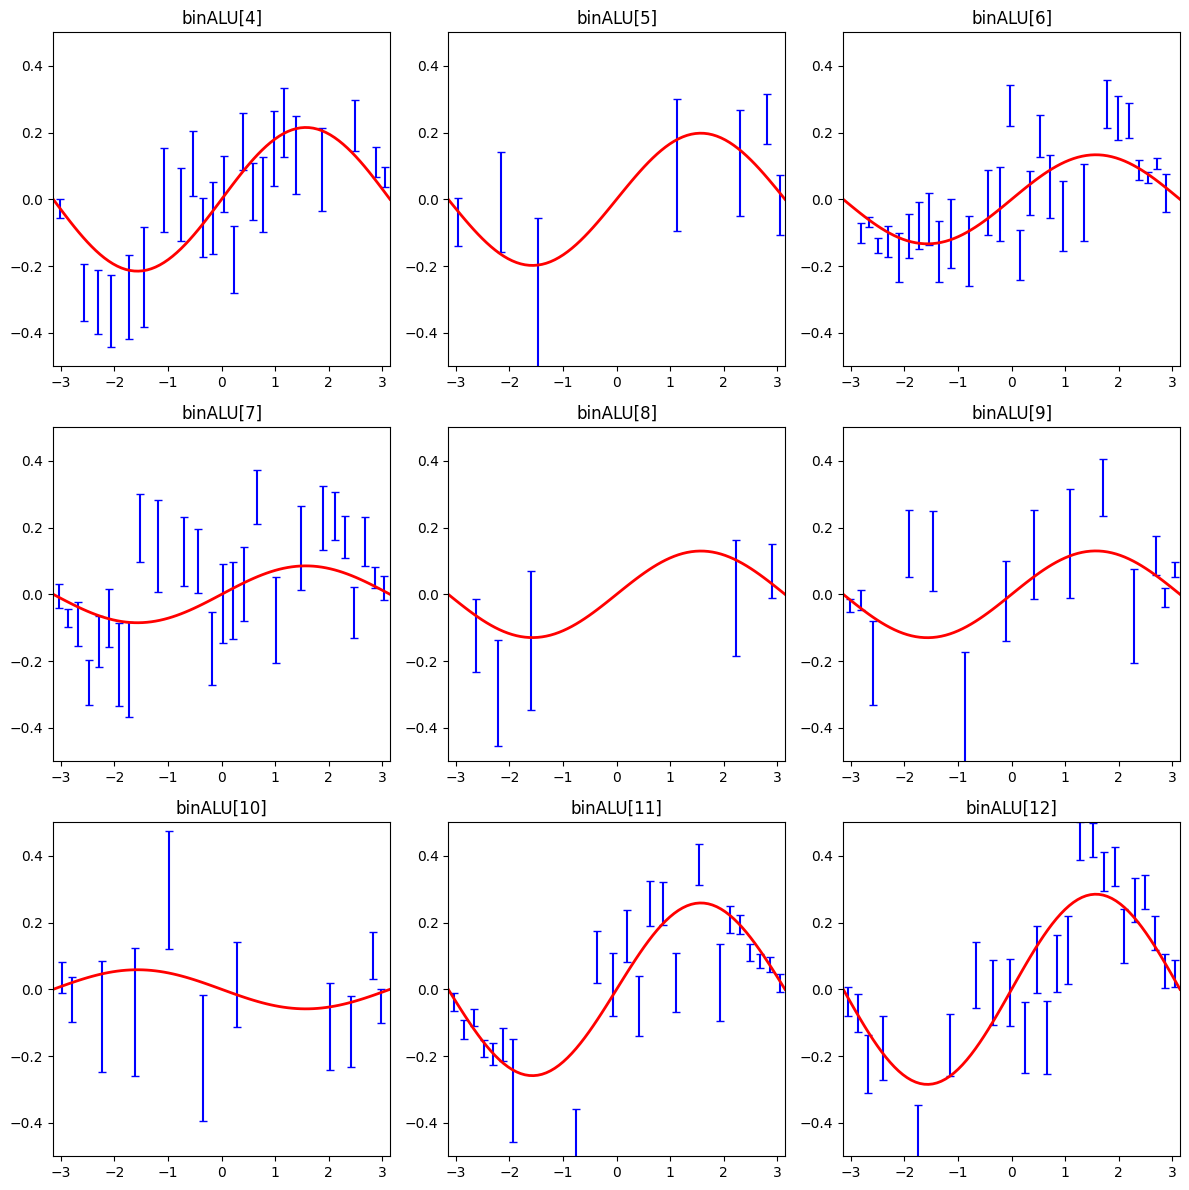

In [31]:
gridplot(4)

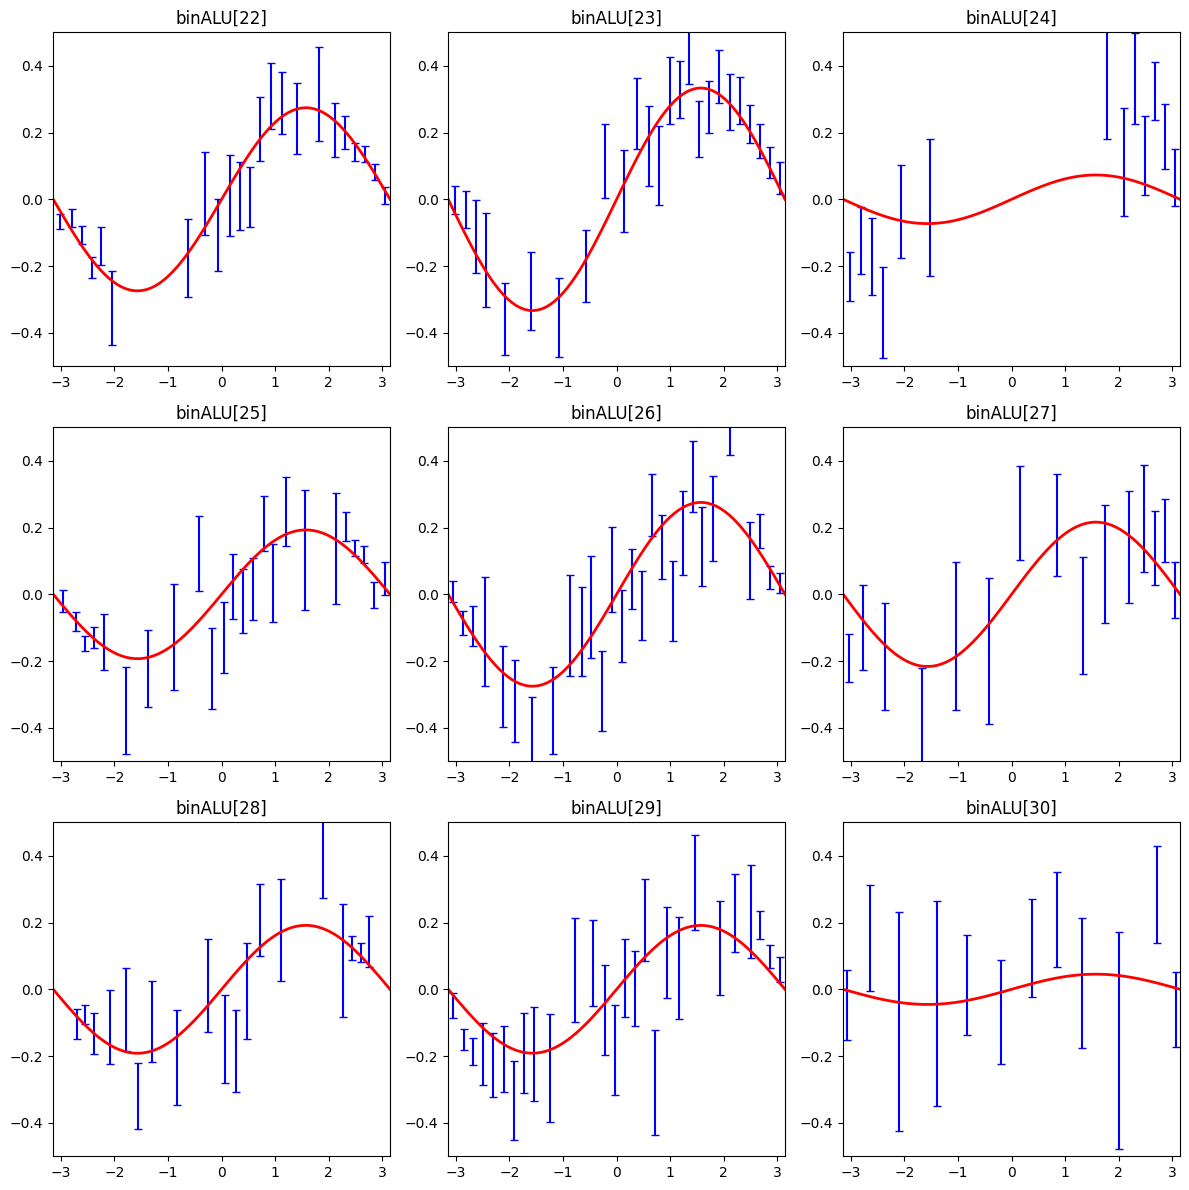

In [32]:
gridplot(22)

Bin 30 is "ugly". Let's compare to simple "clas-like" fit:

In [33]:
binALU[30][['FTval', 'FTerr']].iloc[0]

FTval    0.045303
FTerr    0.113553
Name: 0, dtype: float64

In [34]:
clasfit(binALU[30])

(0.05371424515648975, 0.06591609358690488)

So mean values are reasonably close, while our uncertainty is almost twice as large. Maybe this is good?

On the other hand, bin 26 is "clean" and it shows:

In [35]:
binALU[26][['FTval', 'FTerr']].iloc[0]

FTval    0.275288
FTerr    0.034591
Name: 0, dtype: float64

In [36]:
clasfit(binALU[26])

(0.26988387857619706, 0.03247317466498935)

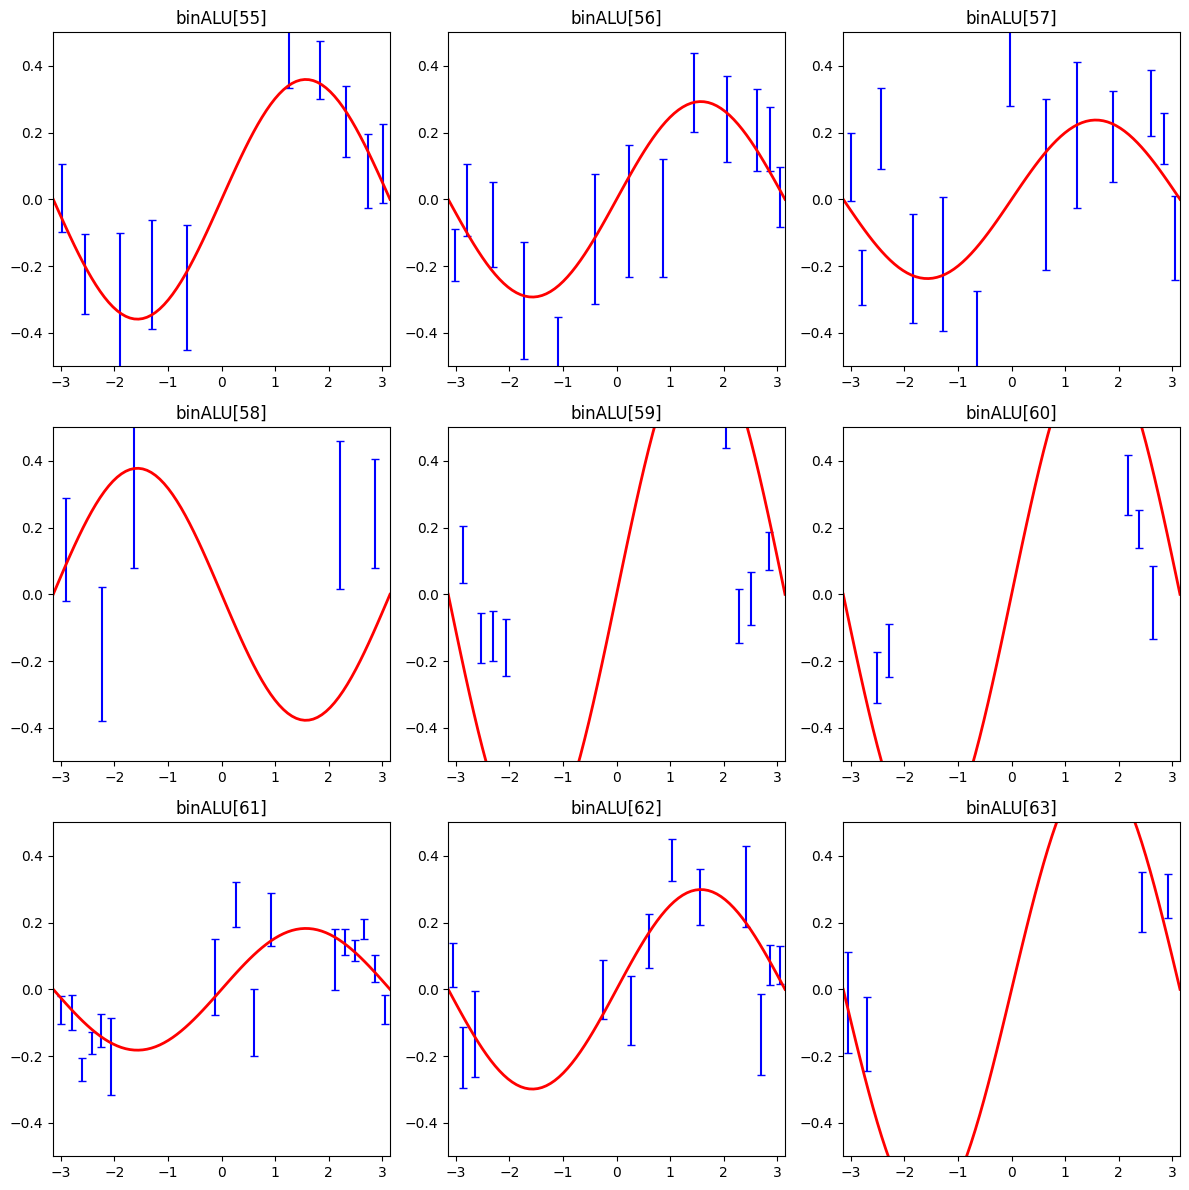

In [37]:
gridplot(55)

Bin 59 looks problematic. Let's see:

In [38]:
binALU[59][['FTval', 'FTerr']].iloc[0]

FTval    0.772508
FTerr    0.171986
Name: 0, dtype: float64

In [39]:
clasfit(binALU[59])

(1447099.555655207, 3770012878937.3877)

# Possible pruning

In fits, one could consider removing data for which the value of the first sine FT harmonic is not statistically consistent with simple CLAS-like fit:

In [41]:
for k, bn in binALU.items():
    s1, dels1 = clasfit(bn)
    mys1 = bn.FTval.iloc[0]
    mydels1 = bn.FTerr.iloc[0]
    nsigmas = abs(s1 - mys1)/mydels1
    if nsigmas > 1:
        print("bin {}: {:.3f}  {:.3f}, {:.1f} sigmas (row {})".format(k, mys1, dels1, nsigmas, k+73))

bin 2: -0.062  0.055, 1.8 sigmas (row 75)
bin 12: 0.285  0.023, 1.9 sigmas (row 85)
bin 27: 0.216  0.052, 1.6 sigmas (row 100)
bin 31: -0.078  0.087, 1.4 sigmas (row 104)
bin 39: 0.324  0.059, 2.5 sigmas (row 112)
bin 52: 0.226  0.075, 1.0 sigmas (row 125)
bin 57: 0.237  0.067, 1.5 sigmas (row 130)
bin 58: -0.377  0.123, 1.5 sigmas (row 131)
bin 59: 0.773  3770012878937.388, 8414056.8 sigmas (row 132)
bin 60: 0.764  802.635, 33.5 sigmas (row 133)
bin 61: 0.182  0.033, 1.4 sigmas (row 134)
bin 65: 0.366  0.077, 1.0 sigmas (row 138)
bin 68: 4.192  0.321, 1.2 sigmas (row 141)
bin 69: 0.190  0.033, 1.5 sigmas (row 142)
bin 70: 0.282  0.024, 1.8 sigmas (row 143)
bin 71: 0.448  1.863, 7.3 sigmas (row 144)
bin 84: 0.295  0.030, 1.0 sigmas (row 157)
bin 88: 0.154  0.075, 2.0 sigmas (row 161)
bin 91: 0.244  0.039, 1.6 sigmas (row 164)
bin 95: 0.302  0.064, 1.8 sigmas (row 168)
bin 101: 0.168  0.414, 1.6 sigmas (row 174)


I commented those out in the datafile ID=150.